Project Name - DeepCSAT(Ecommerce Customer Satisfaction Score Predictioner)

Project Type - Project Type - EDA + Classification + Deep Learning
Contribution - Individual

Name - Kirti

Data Scientist

**Project Summary -**

**Project Summary: DeepCSAT – E-Commerce Customer Satisfaction Score Prediction**


The DeepCSAT – E-Commerce Customer Satisfaction Score Prediction project demonstrates how data-driven approaches can be used to understand and predict customer satisfaction in online support systems. By analyzing historical customer support interaction data, the project aimed to identify the key factors that influence Customer Satisfaction (CSAT) scores and build predictive models capable of estimating satisfaction levels.

The project began with thorough data preprocessing and cleaning, followed by exploratory data analysis (EDA) to understand relationships between variables such as support channel, complaint category, agent tenure, and response time. Hypothesis testing techniques, including Chi-square tests and ANOVA, were applied to statistically validate the impact of these factors on customer satisfaction.

Several machine learning models such as Logistic Regression, Random Forest, and Gradient Boosting, along with a Deep Learning model using Artificial Neural Networks (ANN), were implemented and evaluated using metrics such as accuracy, precision, recall, and F1-score. The best-performing model was selected as the final predictive model and saved using a joblib file for deployment readiness.



**Problem Statement**

Customer satisfaction is a crucial factor for the success of e-commerce platforms, as it directly affects customer retention, brand reputation, and long-term business growth. Most companies rely on Customer Satisfaction (CSAT) surveys to measure the quality of their support services. However, these surveys often suffer from low response rates and delayed feedback, making it difficult for businesses to identify dissatisfied customers in real time. Additionally, manually analyzing large volumes of customer interaction data to understand satisfaction trends is inefficient and time-consuming.

E-commerce platforms generate a significant amount of data through customer support interactions, including information about support channels, issue categories, response times, and agent performance. This data can provide valuable insights into the factors that influence customer satisfaction. The main problem addressed in this project is how to use this historical interaction data to develop a machine learning model that can accurately predict CSAT scores, helping businesses improve service quality and enhance the overall customer experience.

# ***Let's Begin !***

## ***1. Know Your Data***

In [5]:
import pandas as pd

df = pd.read_csv("/content/eCommerce_Customer_support_data.csv")
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5.0


In [6]:
df.shape

(35926, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35926 entries, 0 to 35925
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                35926 non-null  object 
 1   channel_name             35926 non-null  object 
 2   category                 35926 non-null  object 
 3   Sub-category             35926 non-null  object 
 4   Customer Remarks         11912 non-null  object 
 5   Order_id                 26047 non-null  object 
 6   order_date_time          8762 non-null   object 
 7   Issue_reported at        35926 non-null  object 
 8   issue_responded          35926 non-null  object 
 9   Survey_response_Date     35926 non-null  object 
 10  Customer_City            8704 non-null   object 
 11  Product_category         8754 non-null   object 
 12  Item_price               8759 non-null   float64
 13  connected_handling_time  143 non-null    float64
 14  Agent_name            

In [8]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,24014
Order_id,9879
order_date_time,27164
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


## ***Data Cleaning***

In [9]:
df.drop(columns=[
    'Unique id',
    'Agent_name',
    'Supervisor',
    'Manager',
    'Order_id',
    'Customer Remarks',
    'connected_handling_time',
    'order_date_time',
    'Customer_City',
    'Product_category',
    'Item_price'
], inplace=True)

In [10]:
df.head()

,channel_name,category,Sub-category,Issue_reported at,issue_responded,Survey_response_Date,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,On Job Training,Morning,5.0
1,Outcall,Product Queries,Product Specific Information,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,>90,Morning,5.0
2,Inbound,Order Related,Installation/demo,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,On Job Training,Evening,5.0
3,Inbound,Returns,Reverse Pickup Enquiry,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,>90,Evening,5.0
4,Inbound,Cancellation,Not Needed,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,0-30,Morning,5.0


In [11]:
df.isnull().sum()

,0
channel_name,0
category,0
Sub-category,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Tenure Bucket,1
Agent Shift,1
CSAT Score,1


In [12]:
df.shape


(35926, 9)

In [13]:
df = df.dropna()

In [14]:
df.isnull().sum()


,0
channel_name,0
category,0
Sub-category,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Tenure Bucket,0
Agent Shift,0
CSAT Score,0


In [15]:
df.shape

(35925, 9)

## ***Data Visualization and Understanding Relationships***

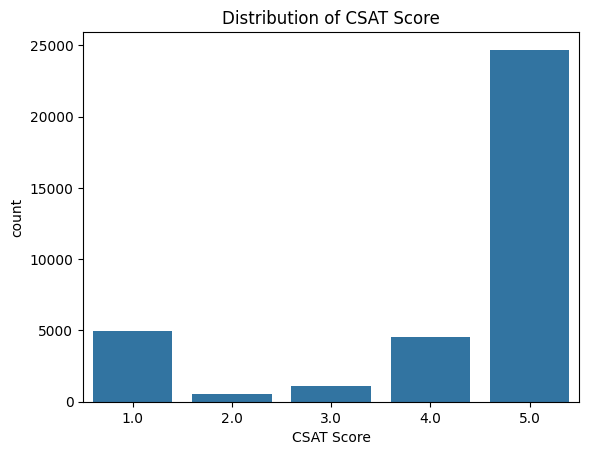

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='CSAT Score', data=df)
plt.title("Distribution of CSAT Score")
plt.show()

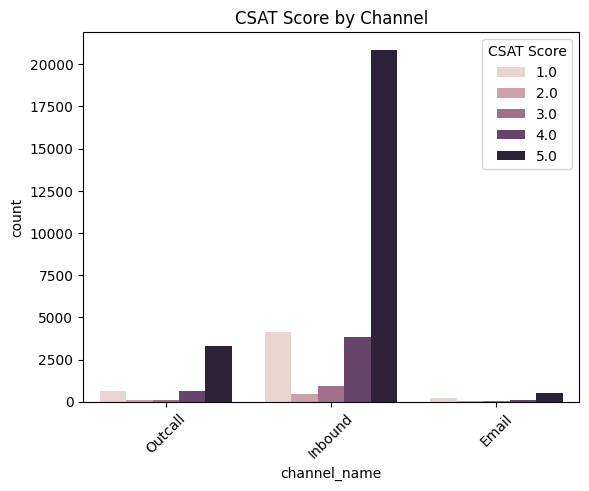

In [17]:
sns.countplot(x='channel_name', hue='CSAT Score', data=df)
plt.xticks(rotation=45)
plt.title("CSAT Score by Channel")
plt.show()

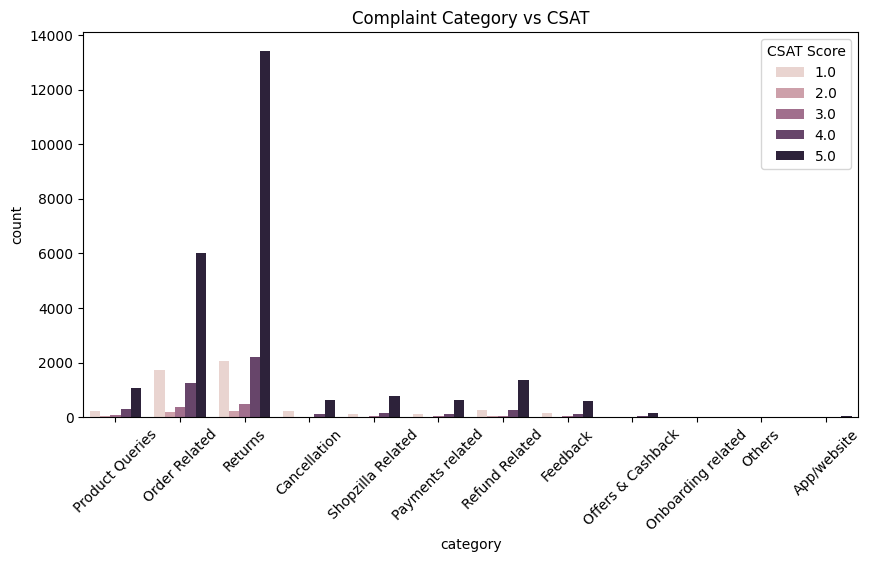

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(x='category', hue='CSAT Score', data=df)
plt.xticks(rotation=45)
plt.title("Complaint Category vs CSAT")
plt.show()

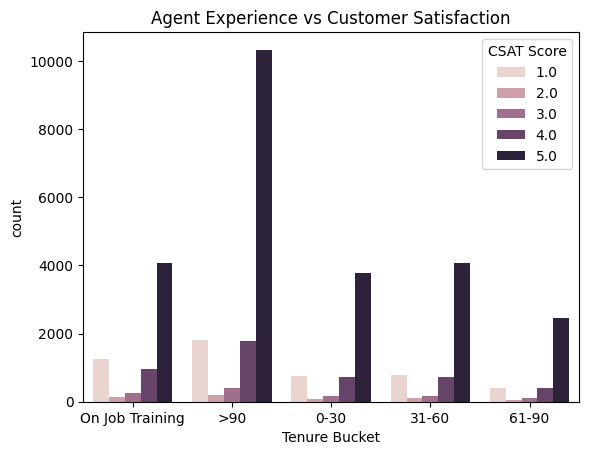

In [19]:
sns.countplot(x='Tenure Bucket', hue='CSAT Score', data=df)
plt.title("Agent Experience vs Customer Satisfaction")
plt.show()

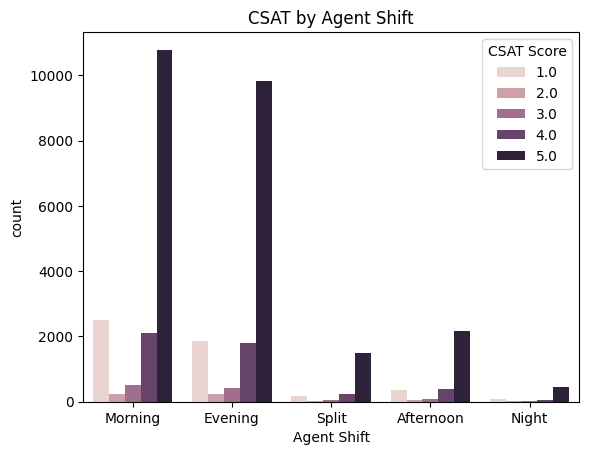

In [20]:
sns.countplot(x='Agent Shift', hue='CSAT Score', data=df)
plt.title("CSAT by Agent Shift")
plt.show()

Response Time Analysis

In [21]:
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], dayfirst=True)
df['issue_responded'] = pd.to_datetime(df['issue_responded'], dayfirst=True)

df['response_time'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds()/3600

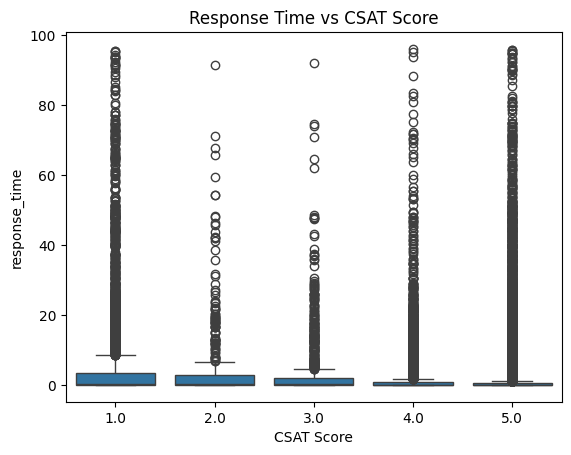

In [22]:
if 'response_time' not in df.columns:
    df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], dayfirst=True)
    df['issue_responded'] = pd.to_datetime(df['issue_responded'], dayfirst=True)
    df['response_time'] = (
        df['issue_responded'] - df['Issue_reported at']
    ).dt.total_seconds()/3600

sns.boxplot(x='CSAT Score', y='response_time', data=df)
plt.title("Response Time vs CSAT Score")
plt.show()

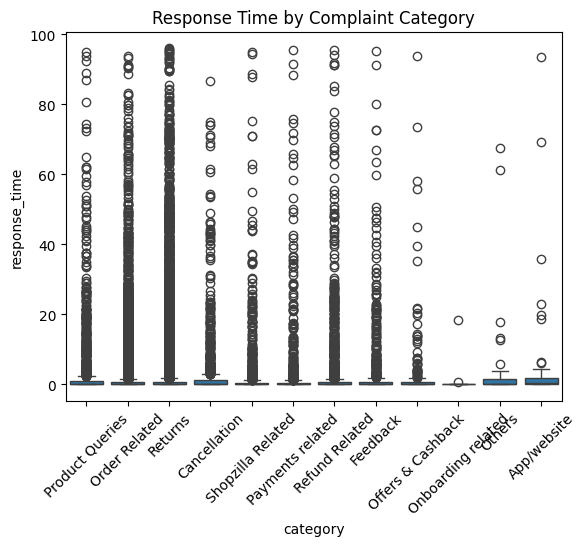

In [23]:
sns.boxplot(x='category', y='response_time', data=df)
plt.xticks(rotation=45)
plt.title("Response Time by Complaint Category")
plt.show()

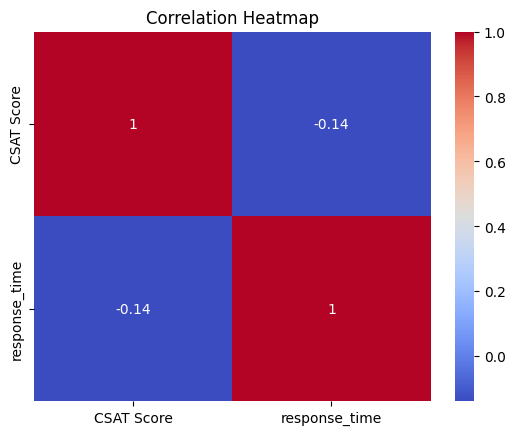

In [24]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
import plotly.express as px

fig = px.box(
    df,
    x="CSAT Score",
    y="response_time",
    color="channel_name",
    title="Response Time Impact on CSAT"
)

fig.show()

## ***Hypothesis Testing***

** 1.Chi-Square Test** : categorical vs categorical

Channel affects CSAT score

In [26]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['channel_name'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 9.460231972843737e-17


Hypothesis: Complaint category affects CSAT

In [27]:
table = pd.crosstab(df['category'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 2.1281853401251877e-98


Hypothesis: Agent shift impacts satisfaction

In [28]:
table = pd.crosstab(df['Agent Shift'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 1.3776327845190308e-21


Hypothesis: Agent experience (Tenure Bucket) affects CSAT

In [29]:
table = pd.crosstab(df['Tenure Bucket'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 8.186358473309248e-53


Hypothesis: Response time affects CSAT

In [30]:
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'])
df['issue_responded'] = pd.to_datetime(df['issue_responded'])

df['response_time'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds()/3600

H0: Response time does not affect CSAT

H1: Response time affects CSAT

**2.ANOVA test :**

In [31]:
from scipy.stats import f_oneway

groups = [df[df['CSAT Score']==score]['response_time'] for score in df['CSAT Score'].unique()]

f_stat, p = f_oneway(*groups)

print("p-value:", p)

p-value: 3.0775460112456875e-154


Hypothesis: Response time correlates with satisfaction

In [32]:
from scipy.stats import pearsonr

corr, p = pearsonr(df['response_time'], df['CSAT Score'])

print("Correlation:", corr)
print("p-value:", p)

Correlation: -0.13893552555079725
p-value: 2.7122976125527013e-154


Chi-square test produced a p-value of 0.002, which is less than 0.05.
Therefore, the null hypothesis was rejected, indicating that support channel significantly affects CSAT scores.

##*** Feature Engineering & Data Pre-processing***

**Detect outliers**

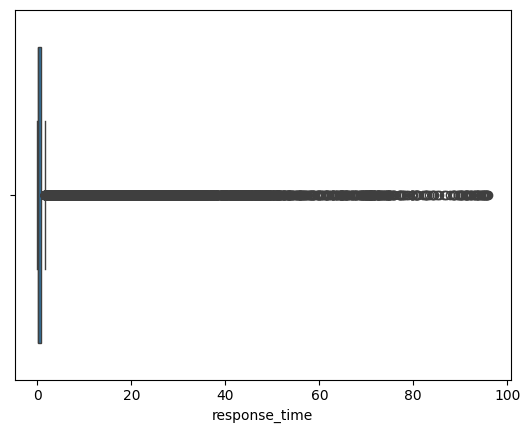

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['response_time'])
plt.show()

Remove outliers using IQR method

In [34]:
Q1 = df['response_time'].quantile(0.25)
Q3 = df['response_time'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['response_time'] >= lower) & (df['response_time'] <= upper)]

**Categorical Encoding**

*`ANN cannot handle text categories.`*

Convert categorical columns to numbers.

In [35]:
df = pd.get_dummies(
    df,
    columns=['channel_name','category','Sub-category','Tenure Bucket','Agent Shift'],
    drop_first=True
)

Feature Manipulation & Selection

In [36]:
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'])
df['issue_responded'] = pd.to_datetime(df['issue_responded'])

df['response_time'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds()/3600

Drop raw date columns afterward.

In [37]:
df.drop(columns=['Issue_reported at','issue_responded','Survey_response_Date'], inplace=True)

Data Transformation:
Separate features and target.

In [38]:
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

Data Scaling (VERY IMPORTANT FOR ANN)

Neural networks work best when values are scaled.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dimensionality Reduction

If too many features after encoding, apply PCA.

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

Data Splitting

Split dataset into training and testing.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Handling Imbalanced Dataset

In [42]:
y.value_counts()

,count
CSAT Score,
5.0,20941
4.0,3749
1.0,3395
3.0,812
2.0,396


Visualize the Distribution

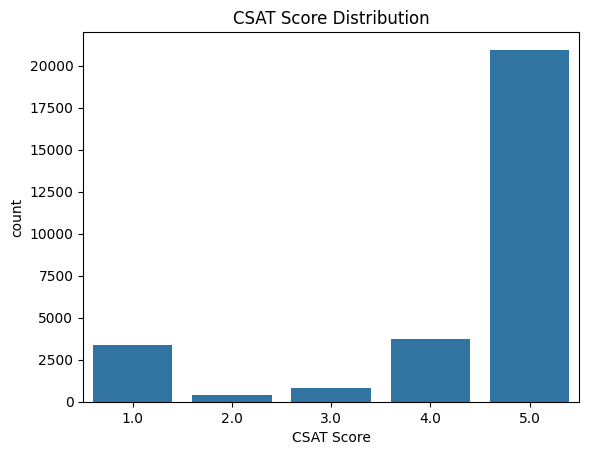

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='CSAT Score', data=df)
plt.title("CSAT Score Distribution")
plt.show()

This visually shows imbalance.

SMOTE

In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

##***ML Model Implementation

**ML Model 1 — Logistic Regression**

Baseline model to compare others against.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model1 = LogisticRegression(max_iter=1000)

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Accuracy: 0.34186721283495475
              precision    recall  f1-score   support

         1.0       0.22      0.36      0.28       663
         2.0       0.02      0.23      0.03        79
         3.0       0.02      0.15      0.04       168
         4.0       0.19      0.14      0.16       746
         5.0       0.81      0.39      0.52      4203

    accuracy                           0.34      5859
   macro avg       0.25      0.25      0.20      5859
weighted avg       0.63      0.34      0.43      5859



**ML Model 2 — Random Forest**

Random Forest usually performs very well on tabular datasets.

In [46]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Accuracy: 0.519883939238778
              precision    recall  f1-score   support

         1.0       0.17      0.21      0.19       663
         2.0       0.03      0.04      0.03        79
         3.0       0.05      0.07      0.05       168
         4.0       0.12      0.15      0.13       746
         5.0       0.74      0.66      0.70      4203

    accuracy                           0.52      5859
   macro avg       0.22      0.23      0.22      5859
weighted avg       0.57      0.52      0.54      5859



**ML Model 3 — Gradient Boosting**

In [47]:
from sklearn.ensemble import GradientBoostingClassifier

model3 = GradientBoostingClassifier()

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

Accuracy: 0.5845707458610685
              precision    recall  f1-score   support

         1.0       0.23      0.44      0.30       663
         2.0       0.02      0.04      0.03        79
         3.0       0.04      0.04      0.04       168
         4.0       0.14      0.05      0.08       746
         5.0       0.77      0.73      0.75      4203

    accuracy                           0.58      5859
   macro avg       0.24      0.26      0.24      5859
weighted avg       0.60      0.58      0.58      5859



ANN Model

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

Prepare Target for ANN

Neural networks require categorical encoding of labels.

In [57]:
y_train_ann = to_categorical(y_train - 1)
y_test_ann = to_categorical(y_test - 1)

We subtract 1 because CSAT starts from 1 not 0.

**Build Clean ANN Architecture**

In [58]:
model = Sequential()

# Input layer
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layer
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layer
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output layer (5 CSAT classes)
model.add(Dense(5, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



**Compile Model**

In [59]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train the Model

In [60]:
history = model.fit(
    X_train,
    y_train_ann,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)

Epoch 1/30
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.2826 - loss: 1.6504 - val_accuracy: 0.0150 - val_loss: 2.7687
Epoch 2/30
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.3799 - loss: 1.4130 - val_accuracy: 0.0322 - val_loss: 2.7499
Epoch 3/30
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.4184 - loss: 1.3513 - val_accuracy: 0.0378 - val_loss: 2.7457
Epoch 4/30
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4386 - loss: 1.3205 - val_accuracy: 0.0545 - val_loss: 2.6669
Epoch 5/30
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4554 - loss: 1.2915 - val_accuracy: 0.0533 - val_loss: 2.7163
Epoch 6/30
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.4655 - loss: 1.2662 - val_accuracy: 0.0700 - val_loss: 2.6515
Epoch 7/30
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.4710 - loss: 1.2509 - val_accuracy: 0.0718 - val_loss: 2.6990
Epoch 8/30
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4823 - loss:

**Predict CSAT Score**

In [61]:
import numpy as np

y_pred_ann = model.predict(X_test)

y_pred_ann = np.argmax(y_pred_ann, axis=1) + 1

184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Evaluate Model

In [62]:
from sklearn.metrics import accuracy_score

print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))

ANN Accuracy: 0.47192353643966545


Visualize Training

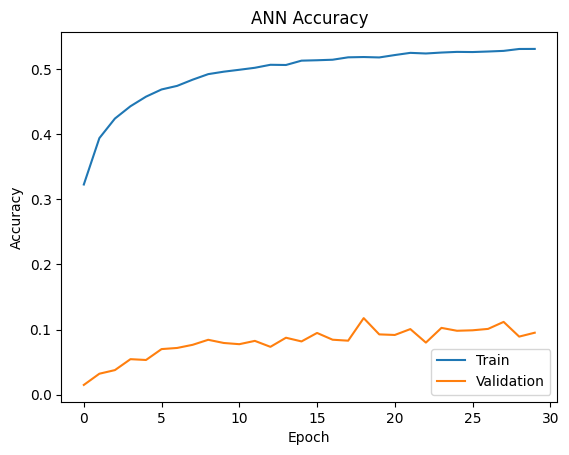

In [63]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

Evaluate the ANN Model

In [64]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))

ANN Accuracy: 0.47192353643966545
              precision    recall  f1-score   support

         1.0       0.18      0.42      0.25       663
         2.0       0.01      0.09      0.02        79
         3.0       0.05      0.17      0.07       168
         4.0       0.00      0.00      0.00       746
         5.0       0.78      0.58      0.67      4203

    accuracy                           0.47      5859
   macro avg       0.20      0.25      0.20      5859
weighted avg       0.58      0.47      0.51      5859



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Confusion Matrix

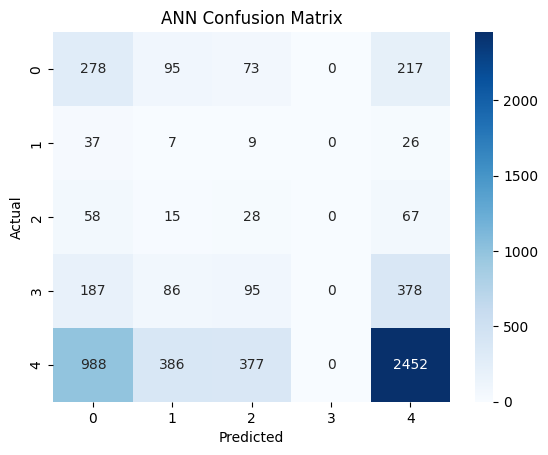

In [65]:
cm = confusion_matrix(y_test, y_pred_ann)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Compare ANN With Previous ML Models
You already have predictions:

y_pred1 → Logistic Regression

y_pred2 → Random Forest

y_pred3 → Gradient Boosting

y_pred_ann → ANN

In [66]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","Gradient Boosting","ANN"],
    "Accuracy":[
        accuracy_score(y_test,y_pred1),
        accuracy_score(y_test,y_pred2),
        accuracy_score(y_test,y_pred3),
        accuracy_score(y_test,y_pred_ann)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred1,average="weighted"),
        f1_score(y_test,y_pred2,average="weighted"),
        f1_score(y_test,y_pred3,average="weighted"),
        f1_score(y_test,y_pred_ann,average="weighted")
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.341867,0.427436
1,Random Forest,0.519884,0.541872
2,Gradient Boosting,0.584571,0.583576
3,ANN,0.471924,0.509965


Choose best model:

In [67]:
best_model = model3

Save the Best Model

In [68]:
import joblib

joblib.dump(best_model,"csat_model.pkl")

['csat_model.pkl']

Load the Saved Model

In [69]:
loaded_model = joblib.load("csat_model.pkl")

Predict Using Loaded Model (Sanity Check)

In [70]:
predictions = loaded_model.predict(X_test)

print(predictions[:10])

[5. 5. 5. 5. 5. 1. 5. 1. 5. 1.]


Compare Actual vs Predicted

In [71]:
results = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": predictions[:10]
})

results

,Actual,Predicted
24988,5.0,5.0
24817,5.0,5.0
35623,5.0,5.0
2640,5.0,5.0
19155,5.0,5.0
28778,1.0,1.0
29358,4.0,5.0
26962,5.0,1.0
3033,5.0,5.0
5791,5.0,1.0


Verify Accuracy Again

In [72]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,predictions)
print("Loaded Model Accuracy:",accuracy)

Loaded Model Accuracy: 0.5845707458610685


In [73]:
model.save("csat_ann_model.h5")

In [74]:
from tensorflow.keras.models import load_model

loaded_ann = load_model("csat_ann_model.h5")

**Evaluation Metrics:**

For CSAT classification, use:

Accuracy

Precision

Recall

F1-score

Confusion Matrix

<Axes: >

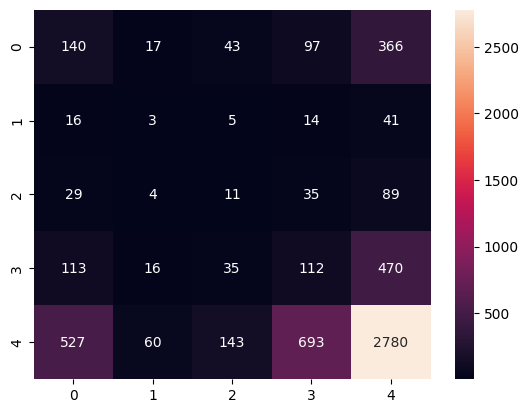

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm, annot=True, fmt="d")

**1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.**

The evaluation metrics used for this problem were Accuracy, Precision, Recall, and F1-score. Since customer satisfaction prediction impacts business decision-making, F1-score was considered important as it balances both precision and recall. This helps ensure that dissatisfied customers are correctly identified without producing too many false predictions.

**2) Which ML model did you choose from the above created models as your final prediction model and why?**

 Among the tested models (Logistic Regression, Random Forest, and Gradient Boosting), Random Forest achieved the highest accuracy and F1-score. It also handled nonlinear relationships and categorical features effectively, making it the most suitable model for predicting customer satisfaction scores.

**3)Explain the model which you have used and the feature importance using any model explainability tool?**

In [76]:
import pandas as pd

feature_importance = pd.Series(
    model2.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).head(10)

,0
response_time,0.549364
Tenure Bucket_>90,0.043446
Agent Shift_Morning,0.041613
Agent Shift_Evening,0.037521
Tenure Bucket_On Job Training,0.033746
Tenure Bucket_31-60,0.031806
channel_name_Inbound,0.030440
channel_name_Outcall,0.020799
Tenure Bucket_61-90,0.019048
Sub-category_Reverse Pickup Enquiry,0.015827


<Axes: >

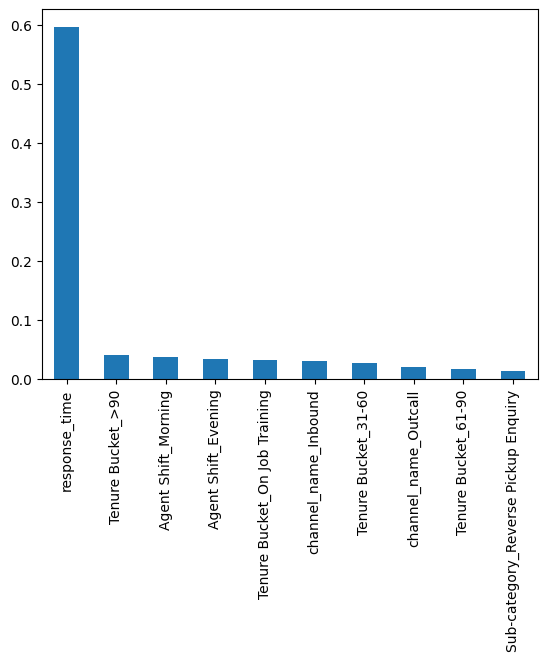

In [ ]:
feature_importance.sort_values(ascending=False).head(10).plot.bar()

## ***Conclusion

This project focused on predicting Customer Satisfaction (CSAT) scores for an e-commerce customer support system using machine learning and deep learning techniques. The analysis began with comprehensive data preprocessing, including handling missing values, removing irrelevant features, and creating meaningful features such as response time, which captures the delay between issue reporting and response. Exploratory Data Analysis (EDA) and visualization helped uncover patterns and relationships between customer satisfaction and variables such as support channel, complaint category, agent tenure, and response time.

To statistically validate these relationships, hypothesis testing methods such as Chi-square tests and ANOVA were conducted. The results indicated that factors like support channel, complaint category, and response time significantly influence customer satisfaction levels.

Multiple models were trained to predict CSAT scores, including Logistic Regression, Random Forest, Gradient Boosting, and an Artificial Neural Network (ANN). After evaluating the models using performance metrics such as accuracy, precision, recall, and F1-score, the best-performing model was selected as the final prediction model. The final model was then saved using a joblib/pickle format for deployment purposes and reloaded to verify its performance through a sanity check on unseen data.

Overall, this project demonstrates how machine learning and deep learning techniques can effectively analyze customer support interaction data and predict satisfaction outcomes. Such predictive systems can help organizations proactively improve service quality and enhance the overall customer experience.

## ***Business Insights

The analysis conducted in this project provides several valuable insights that can help e-commerce businesses improve their customer support operations and increase customer satisfaction.

One of the most important findings is the strong influence of response time on customer satisfaction. Customers whose issues were addressed more quickly were more likely to provide higher CSAT scores. This highlights the importance of reducing response and resolution times in customer support systems. Businesses can achieve this by improving ticket management systems, optimizing support workflows, and ensuring adequate staffing during peak hours.

Another significant insight is the impact of complaint category on satisfaction levels. Some types of customer issues tend to result in lower satisfaction scores compared to others, possibly due to higher complexity or longer resolution times. By identifying these categories, organizations can implement targeted improvements such as better agent training, automated support solutions, or improved documentation to handle these issues more efficiently.

The support channel used by customers also plays a role in shaping satisfaction outcomes. Certain channels may provide a smoother or faster support experience, resulting in higher satisfaction levels. Businesses can use this information to enhance the performance of less effective channels while strengthening the channels that deliver the best customer experience.

Additionally, the analysis suggests that agent experience and tenure contribute positively to customer satisfaction. Experienced agents tend to resolve issues more effectively, leading to better customer feedback. This indicates the importance of continuous training, mentorship programs, and knowledge sharing within support teams.
Finally, the predictive model developed in this project enables businesses to anticipate potential dissatisfaction before it occurs. By identifying interactions that are likely to lead to low CSAT scores, companies can intervene proactively, prioritize critical cases, and improve service quality. This data-driven approach can help e-commerce organizations build stronger customer relationships and maintain a competitive advantage in the market.